This notbook is used to demonstrate building classification models using tree-based classifiers. The dataset used for this exercise is borrowed from [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients).

### Import packages

In [1]:
import pandas as pd

### Set-up

In [2]:
# input file location and name
infile = 'https://raw.githubusercontent.com/vishal-git/dapt-631/main/data/credit_default_model_data.csv'

# target variable (column name)
target = 'default payment next month'

### Read data

In [3]:
df = pd.read_csv(infile)
df.shape

(30000, 57)

In [4]:
df.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,pay_bucket_-2_flag,pay_bucket_-1_flag,pay_amt_total,bill_amt_total,pay_to_billed_ratio,zero_bill_amount,utilization_avg,utilization_max,group,default payment next month
0,40000,28,10371,11895,11228,2475,5341,6255,2567,0,...,0,1,11883,47565,0.249827,0,0.198187,0.297375,M,1
1,320000,35,12233,16490,20011,17918,18627,19167,7000,4100,...,0,0,15100,104446,0.144572,0,0.054399,0.062534,M,0
2,260000,35,188,188,188,188,194,188,188,188,...,0,1,1167,1134,1.029101,0,0.000727,0.000746,M,0
3,360000,36,308711,305594,306176,304645,315118,315782,11000,13000,...,0,0,71322,1856026,0.038427,0,0.859271,0.877172,M,0
4,500000,25,-46,9412,1260,0,1121,6566,9458,1260,...,0,1,20839,18313,1.137935,0,0.006104,0.018824,M,0


In [5]:
df.group.value_counts()

group
M    15000
T     7500
V     7500
Name: count, dtype: int64

In [6]:
y = df[target]
X = df.drop(target, axis=1)

X_train = X[X['group'] == 'M'].drop('group', axis=1)
X_test = X[X['group'] == 'T'].drop('group', axis=1)
X_valid = X[X['group'] == 'V'].drop('group', axis=1)

y_train = y[X['group'] == 'M']
y_test = y[X['group'] == 'T']
y_valid = y[X['group'] == 'V']

len(X_train), len(X_test), len(X_valid)

(15000, 7500, 7500)

In [7]:
del df

### Initial Models

In [ ]:
# import sklearn classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# define classifiers
models = {
    'LR': LogisticRegression(max_iter=1000, random_state=314),
    'DT': DecisionTreeClassifier(random_state=314),
    'RF': RandomForestClassifier(n_estimators=50, random_state=314),
    'GB': GradientBoostingClassifier(n_estimators=50, random_state=314),
}

# colors for plots
model_colors = {
    'LR': 'royalblue',
    'DT': 'olive',
    'RF': 'darkorange',
    'GB': 'purple',
}

Fit the models.

In [9]:
for model in models.values():
    model.fit(X_train, y_train)

/home/vishal/code/dapt-631/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Save the predicted probabilities (scores) for the train and test paritions for each model.

In [10]:
def get_scores(model_dict, X):
    scores = {}
    for key, model in model_dict.items():
        scores[key] = model.predict_proba(X)[:, 1]
    return scores

scores_train = get_scores(models, X_train)
scores_test = get_scores(models, X_test)

### ROC Curves

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score


def get_roc_info(y_true, score_dict):
    roc_info = {}
    for key, scores in score_dict.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc = roc_auc_score(y_true, scores)
        roc_info[key] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    return roc_info


roc_train = get_roc_info(y_train, scores_train)
roc_test = get_roc_info(y_test, scores_test)

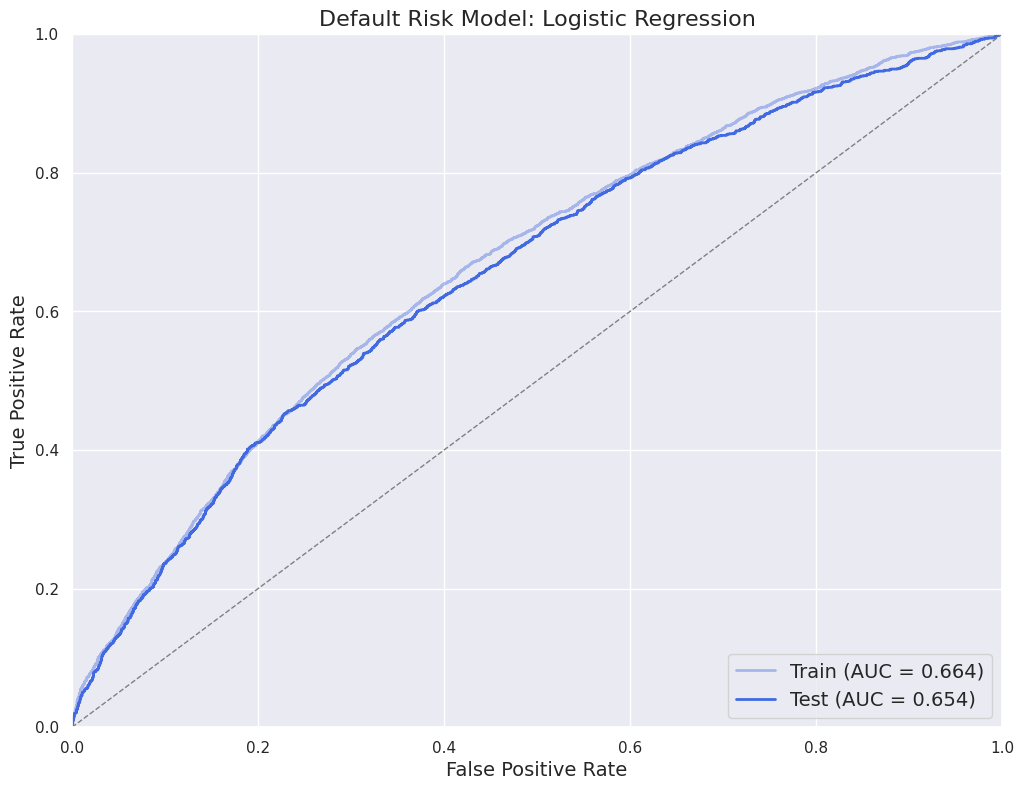

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')
plt.figure(figsize=(12, 9))

# logistic regression only (train vs test)
plt.plot(roc_train['LR']['fpr'], roc_train['LR']['tpr'], color=model_colors['LR'], lw=2, alpha=0.4,
         label=f"Train (AUC = {roc_train['LR']['auc']:0.3f})")

plt.plot(roc_test['LR']['fpr'], roc_test['LR']['tpr'], color=model_colors['LR'], lw=2,
         label=f"Test (AUC = {roc_test['LR']['auc']:0.3f})")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Default Risk Model: Logistic Regression', fontsize=16)
plt.legend(loc='lower right', fontsize=14);

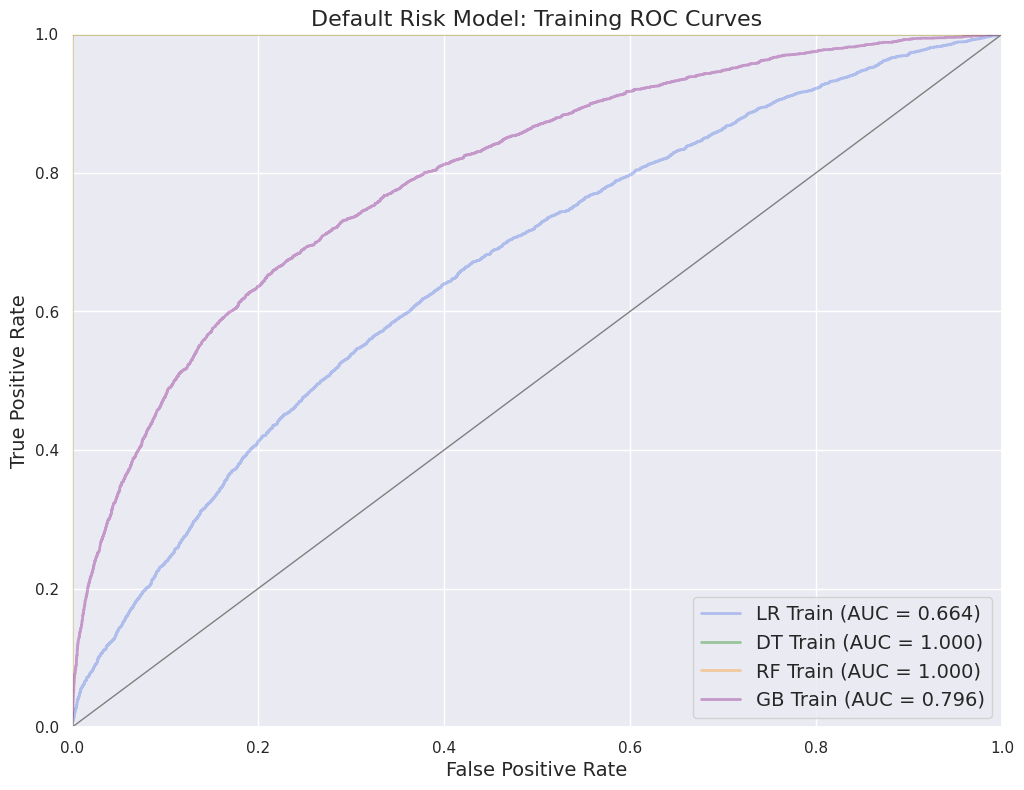

In [13]:
plt.figure(figsize=(12, 9))

for key in ['LR', 'DT', 'RF', 'GB']:
    plt.plot(
        roc_train[key]['fpr'],
        roc_train[key]['tpr'],
        color=model_colors[key],
        lw=2,
        alpha=0.35,
        label=f"{key} Train (AUC = {roc_train[key]['auc']:0.3f})",
    )

plt.plot([0, 1], [0, 1], color='gray', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Default Risk Model: Training ROC Curves', fontsize=16)
plt.legend(loc='lower right', fontsize=14);

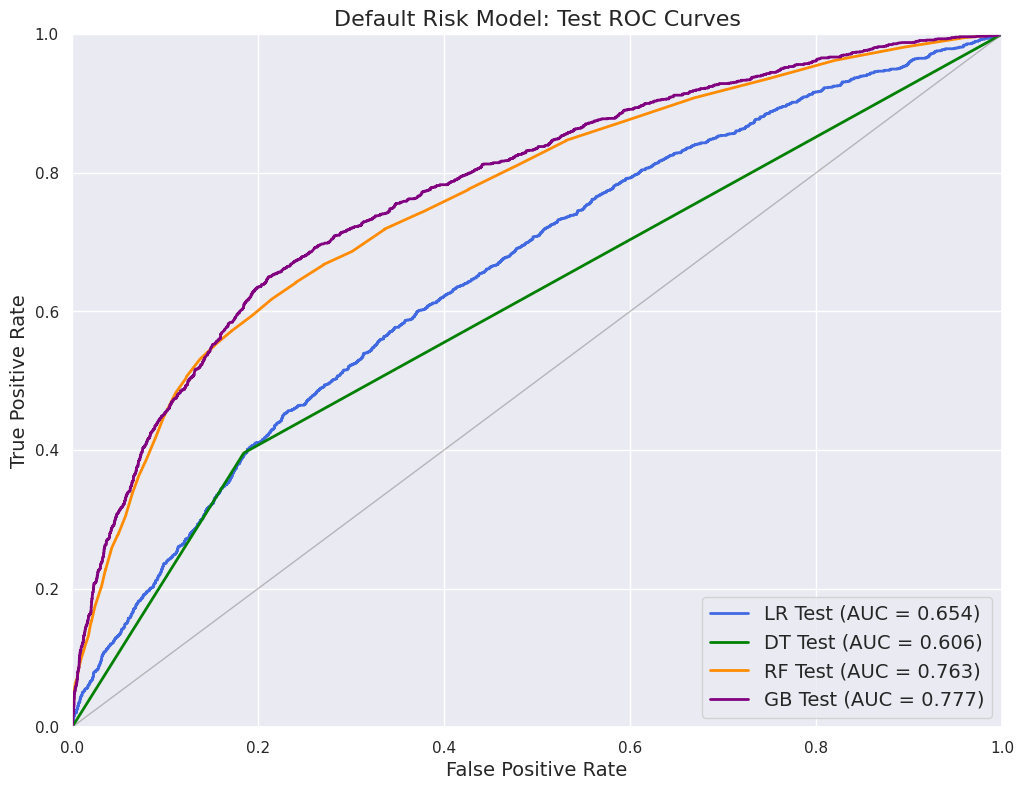

In [14]:
plt.figure(figsize=(12, 9))

for key in ['LR', 'DT', 'RF', 'GB']:
    plt.plot(
        roc_test[key]['fpr'],
        roc_test[key]['tpr'],
        color=model_colors[key],
        lw=2,
        label=f"{key} Test (AUC = {roc_test[key]['auc']:0.3f})",
    )

plt.plot([0, 1], [0, 1], color='gray', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Default Risk Model: Test ROC Curves', fontsize=16)
plt.legend(loc='lower right', fontsize=14);

We haven't standardized the input features. Let's see what happens when we do that.

### Logistic Regression *with Standardization*

In [15]:
from sklearn.preprocessing import StandardScaler

# define a scaler
X_scaler = StandardScaler()

# fit a new logistic model on standardized features
logit_std = LogisticRegression(max_iter=1000, random_state=314)
logit_std.fit(X_scaler.fit_transform(X_train.astype(float)), y_train)

# get model scores
logit_std_scores_test = logit_std.predict_proba(X_scaler.transform(X_test.astype(float)))[:, 1]

# calculate ROC values
logit_std_fpr_test, logit_std_tpr_test, _ = roc_curve(y_test, logit_std_scores_test)
logit_std_auc_test = roc_auc_score(y_test, logit_std_scores_test)

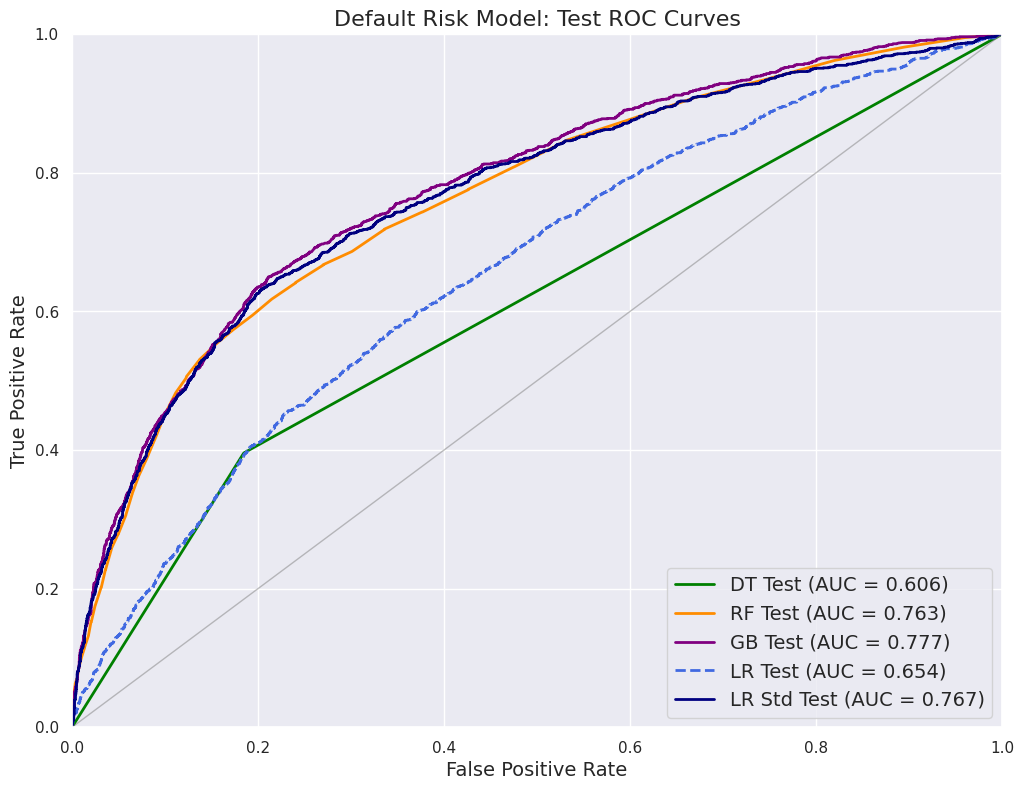

In [17]:
plt.figure(figsize=(12, 9))

# models without standardization
for key in ['DT', 'RF', 'GB']:
    plt.plot(
        roc_test[key]['fpr'],
        roc_test[key]['tpr'],
        color=model_colors[key],
        lw=2,
        label=f"{key} Test (AUC = {roc_test[key]['auc']:0.3f})",
    )

# logistic regression with and without standardization
plt.plot(
    roc_test['LR']['fpr'],
    roc_test['LR']['tpr'],
    color='royalblue',
    lw=2,
    linestyle='--',
    label=f"LR Test (AUC = {roc_test['LR']['auc']:0.3f})",
)

plt.plot(
    logit_std_fpr_test,
    logit_std_tpr_test,
    color='navy',
    lw=2,
    label=f"LR Std Test (AUC = {logit_std_auc_test:0.3f})",
)

plt.plot([0, 1], [0, 1], color='gray', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Default Risk Model: Test ROC Curves', fontsize=16)
plt.legend(loc='lower right', fontsize=14);

A single decision tree severely overfit the training set and generalized poorly. Random Forest and Gradient Boosting performed better on test data because ensemble learning reduces overfitting and improves generalization, even before hyperparameter tuning.

In the next session, we will work on optimizing the model hyper-parameters to try to improve their performance. 